# 第三部分：巴西电商用户行为分析 - 可视化分析与业务洞察
## 3.可视化分析与业务洞察
## 3.1用户行为分析
- ### 3.1.1 用户订单分布（验证用户只有一个订单）
- ### 3.1.2用户消费能力
- - 3.1.2.1用户客单价箱线图
- - 3.1.2.2查找极端高客单价的异常值和处理异常值
用于分析异常值是否合理
- - 3.1.2.3查找0元订单的异常值和处理异常值
用于分析异常值是否合理
- ### 3.1.3 用户活跃时间
- - 3.1.3.1每月订单量趋势
- - 3.1.3.2每月订单量折线图
## 3.2订单表现分析
- ### 3.2.1订单金额分布
- - 3.2.1.1订单总金额（含运费）直方图
  - 3.2.1.2不同金额区间订单占比饼图
- ### 3.2.2配送时效分析
- - 3.2.2.1配送时长分布直方图
- - 3.2.2.2延迟订单占比饼图
## 3.3产品表现分析
- ### 3.3.1品类销售排行
- - 3.3.1.1销售额前10品类柱状图
- - 3.3.1.2销量前10品类柱状图

##

## 3.可视化分析与业务洞察

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文显示，作用于 matplotlib/seaborn 绘制的图表
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # Mac中文显示
plt.rcParams['axes.unicode_minus'] = False

In [216]:
# 加载客户-明细表
# customer_order_merge = pd.read_csv('brazil_ecommerce_project/merges/customer_order_merge.csv')

#加载订单明细表
order_merge = pd.read_csv('brazil_ecommerce_project/merges/order_merge.csv')

#加载产品-商家表
# product_seller_merge = pd.read_csv('brazil_ecommerce_project/merges/product_seller_merge.csv')

In [217]:
# 加载用户特征表
user_features = pd.read_csv('brazil_ecommerce_project/features/user_features.csv')

#加载订单特征表
order_features = pd.read_csv('brazil_ecommerce_project/features/order_features.csv')

#加载产品特征表
category_features = pd.read_csv('brazil_ecommerce_project/features/category_features.csv')

#####

## 3.1用户行为分析

## 3.1.1 用户订单分布（验证用户只有一个订单）

<Axes: title={'center': '客户订单分布'}, xlabel='订单数', ylabel='用户数'>

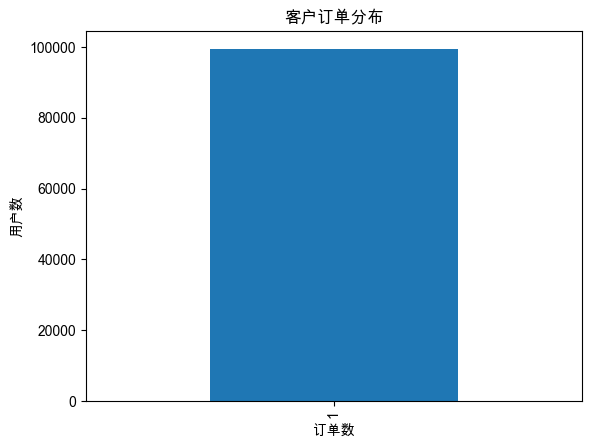

In [218]:
# 订单数分布直方图（展示不同订单数对应的用户数量）
order_count = user_features['order_count'].value_counts()
order_count.plot.bar(title='客户订单分布', xlabel='订单数', ylabel='用户数')

#### 结论：由于数据中所有用户的订单数都是1（之前已验证），所以图表只显示一根柱子，高度为99441。

#####

## 3.1.2用户消费能力

### 3.1.2.1用户客单价箱线图

<Axes: title={'center': '用户客单价箱线图'}>

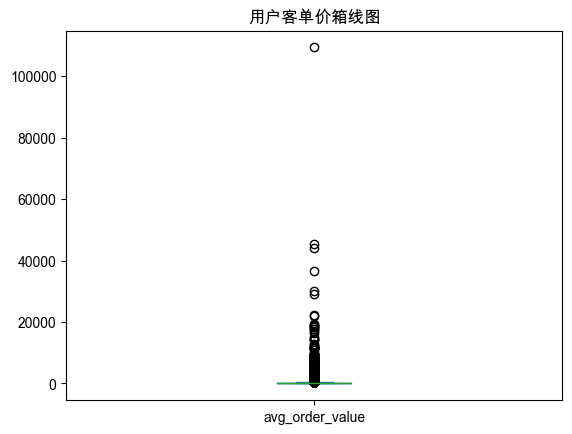

In [219]:
# 客户单价分布箱线图
user_features['avg_order_value'].plot.box(title='用户客单价箱线图')

### 结论：存在极端高客单价和少量0元订单

#####

### 3.1.2.2查找极端高客单价的异常值和处理异常值
用于分析异常值是否合理

In [220]:
# 取客单价里最大的10个值，看是否属于真的异常值
# 利用 merge 将用户特征表、客户-订单表连接起来
user_check = user_features[['customer_id', 'avg_order_value']].merge(customer_order_merge[[
    'customer_id', 'order_id']], on='customer_id', how='left')

# 再把产品-商家表连接起来
user_check = user_check.merge(product_seller_merge[[
    'order_id', 'product_category_name','product_id']], on='order_id', how='left')

# 有的用户购买了多个商品,导致 merge 后该用户出现多行
# 去重保留第一次出现的商品类别
user_check = user_check.drop_duplicates(subset=['customer_id', 'avg_order_value'])

# 取客单价里最大的10个值
user_check[['customer_id', 'avg_order_value', 'product_category_name'
           ]].nlargest(10,'avg_order_value')


,customer_id,avg_order_value,product_category_name
9793,1617b1357756262bfa56ab541c47bc16,109312.64,telefonia_fixa
84217,bd5d39761aa56689a265d95d8d32b8be,45256.00,automotivo
84520,be1b70680b9f9694d8c70f41fa3dc92b,44048.00,informatica_acessorios
2396,05455dfa7cd02f13d132aa7a6a9729c6,36489.24,agro_industria_e_comercio
14199,1ff773612ab8934db89fd5afa8afe506,30186.00,bebidas
104911,ec5b2ba62e574342386871631fafd3fc,29099.52,telefonia_fixa
102925,e7d6802668de6e74d0d6c56565bf2a24,22346.60,moveis_escritorio
62023,8c20d9bfbc96c5d39025d77a3ba83d7f,21874.05,moveis_escritorio
109679,f7622098214b4634b7fe7eee269b5426,19457.04,sinalizacao_e_seguranca
50213,71901689c5f3e5adc27b1dd16b33f0b8,19174.38,informatica_acessorios


### 结论：高客单价品类集中在大件 / 高价值商品（固定电话、汽车、办公家具、安防设备等）

In [221]:
# 筛选出高客单价用户的订单明细（以客单价最高的用户为例）
high_user = user_check.nlargest(10,'avg_order_value')['customer_id'].tolist()
high_order = order_merge[order_merge['customer_id'].isin(high_user)]

# 查看这些订单的详细商品信息(商品件数，总价，以及对应的产品类别）
high_orders = high_order.groupby('order_id').agg(order_count=('order_id','count'), avg_price=(
    'payment_value','mean'), total_price=('payment_value', 'sum')).sort_values(
    'total_price', ascending=False).reset_index()

# 连接user_check表，用于查看件数和总价对应的产品类别
high_orders = high_orders.merge(user_check[['order_id', 'product_category_name'
                             ]], on='order_id', how='left')
high_orders

,order_id,order_count,avg_price,total_price,product_category_name
0,03caa2c082116e1d31e67e9ae3700499,8,13664.08,109312.64,telefonia_fixa
1,ab14fdcfbe524636d65ee38360e22ce8,20,2262.80,45256.00,automotivo
2,1b15974a0141d54e36626dca3fdc731a,20,2202.40,44048.00,informatica_acessorios
3,2cc9089445046817a7539d90805e6e5a,6,6081.54,36489.24,agro_industria_e_comercio
4,e8fa22c3673b1dd17ea315021b1f0f61,10,3018.60,30186.00,bebidas
5,736e1922ae60d0d6a89247b851902527,4,7274.88,29099.52,telefonia_fixa
6,9aec4e1ae90b23c7bf2d2b3bfafbd943,10,2234.66,22346.60,moveis_escritorio
7,71dab1155600756af6de79de92e712e3,11,1988.55,21874.05,moveis_escritorio
8,912343626f370ead5ef2e85a9d757e22,6,3242.84,19457.04,sinalizacao_e_seguranca
9,4412d97cb2093633afa85f11db46316c,6,3195.73,19174.38,informatica_acessorios


### 从分析结果可以看出，客单价最高的10个订单具有以下特征：
- 商品件数较多（4至20件），平均单价显著高于普通订单。
- 产品类别集中在固定电话设备、汽车配件、信息技术配件、农业工业、饮料、办公家具、安全标识等偏向工业或商业用途的品类。
- 这些品类多为企业级采购或大宗交易，而非普通消费品，因此高客单价可能是合理的批量采购行为，而非数据错误。

### 结论：
- 高客单价订单主要由企业级或批量采购驱动，集中在特定工业/商业品类，建议在后续分析中将其作为独立群体研究，或为这类客户提供定制化服务。

#####

### 3.1.2.3查找0元订单的异常值和处理异常值
用于分析异常值是否合理

In [222]:
# 筛选出高0元客单价用户的订单明细（以客单价0元的用户为例）
zero_orders = user_features[user_features['avg_order_value'] == 0]['customer_id'].tolist()
zero_orders_info = order_merge[order_merge['customer_id'].isin(zero_orders)]

# 查找重复值并去重
zero_orders_info.duplicated('order_id')
zero_orders_info = zero_orders_info.drop_duplicates(['order_id','customer_id'])

# 查看0元客单价的订单明细
zero_orders_info[[
    'order_id', 'customer_id','order_status', 'order_delivered_customer_date', 'payment_value']]

,order_id,customer_id,order_status,order_delivered_customer_date,payment_value
1362,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,NaN,0.0
36864,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-11-09 07:47:38,NaN
47855,4637ca194b6387e2d538dc89b124b0ee,a73c1f73f5772cf801434bf984b0b1a7,canceled,NaN,0.0
48231,c8c528189310eaa44a745b8d9d26908b,197a2a6a77da93f678ea0d379f21da0a,canceled,NaN,0.0


### 经排查，共发现4个0元订单，其中3个为已取消订单（状态正常），1个为数据异常（已送达但支付金额缺失）
建议删除已送达但金额缺失的这笔订单（因为它会影响客单价、销售额等指标），其余3笔取消的0元订单可保留

In [223]:
# 删除指定订单
order_merge = order_merge[order_merge['order_id'] != 'bfbd0f9bdef84302105ad712db648a6c']
order_features = order_features[order_features['order_id'] != 'bfbd0f9bdef84302105ad712db648a6c']

# 删除指定用户
user_features = user_features[user_features['customer_id'] != '86dc2ffce2dfff336de2f386a786e574']

#####

## 3.1.3 用户活跃时间

### 3.1.3.1每月订单量趋势

In [224]:
# 先去重,因为一个订单可能有多个商品，但只能算一个订单
monthly_orders = order_merge.drop_duplicates(['order_id', 'customer_id']).copy()

#设置时间格式
monthly_orders['order_purchase_timestamp'] = pd.to_datetime(monthly_orders[
    'order_purchase_timestamp'])

#设置购买时间列为索引
monthly_orders = monthly_orders.set_index('order_purchase_timestamp')

#降采样，计算每月的订单数
monthly_orders = monthly_orders['order_id'].resample('ME').count()

#时间索引转换到月周期
monthly_orders.index = monthly_orders.index.to_period()
#重置索引
monthly_orders = monthly_orders.reset_index()
#重置列名
monthly_orders.rename(columns={'order_purchase_timestamp':'monthly','order_id':'order_count'
                              }, inplace=True)
monthly_orders.head()

,monthly,order_count
0,2016-09,3
1,2016-10,324
2,2016-11,0
3,2016-12,1
4,2017-01,800


### 3.1.3.2每月订单量折线图

<Axes: title={'center': '每月订单量趋势'}, xlabel='monthly_str'>

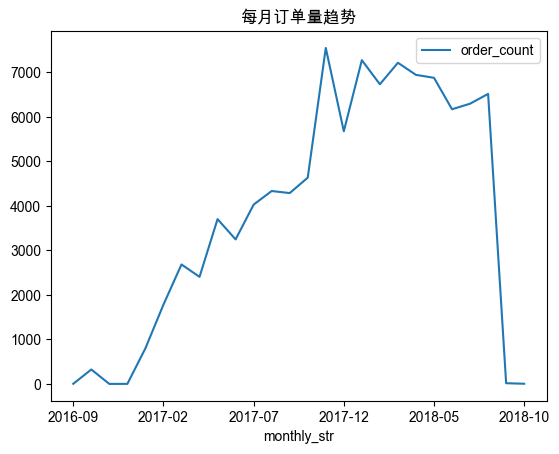

In [225]:
# 先把 monthly 列转成「年-月」字符串格式,用于横坐标显示完整的时间
monthly_orders['monthly_str'] = monthly_orders['monthly'].astype(str)

# 每月订单量折线图
monthly_orders.plot(x='monthly_str', y='order_count', title='每月订单量趋势')

### 结论：
- 整体增长：从2016年9月至2018年10月，订单量呈现显著上升趋势，10月订单量回落至27单
- 起步期（2016年9月—12月）：订单量极少，月均不足百单，属于数据积累初期。
- 快速增长期（2017年—2018年）：2017年初订单量突破800，此后稳步攀升，至2018年下半年月订单量超过7000，增长近10倍。
- 异常月份：2016年11月订单量为0，可能是数据缺失或业务暂停，需注意数据覆盖的完整性。

#####

## 3.2订单表现分析

## 3.2.1订单金额分布

### 3.2.1.1订单总金额（含运费）直方图

<Axes: title={'center': '订单金额分布（0-1000元区间）'}, xlabel='订单金额（元）', ylabel='订单数'>

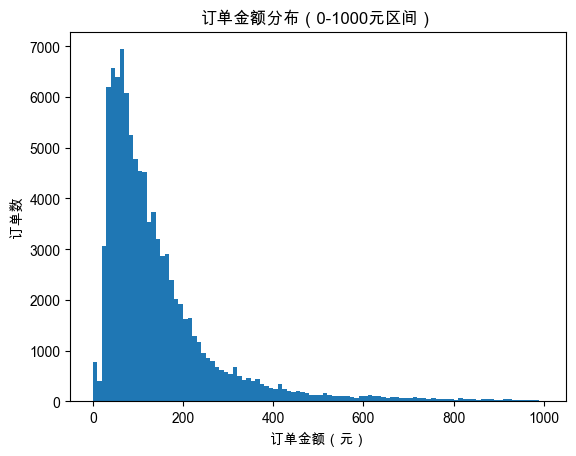

In [226]:
# 订单总金额直方图
order_features['order_total_price'].plot.hist(bins=100,range=(
    0, 1000), title='订单金额分布（0-1000元区间）', xlabel='订单金额（元）', ylabel='订单数')

In [227]:
order_features['order_total_price'].describe(percentiles=[.5, .9, .95])

count    99440.000000
mean       167.373168
std        255.146949
min          0.000000
50%        106.970000
90%        318.920000
95%        478.263500
max      13664.080000
Name: order_total_price, dtype: float64

### 结论：
- 订单金额中位数为106.97元，平均值为167.37元，说明半数以上订单金额在107左右，均值高于中位数反映分布右偏。
- 分布范围：90% 的订单金额在 318.92 元以下，95% 在478.26元以下，表明绝大部分订单集中于 0–500 元区间，与直方图显示一致。
- 极端值：存在少量极高金额订单（最大值达 109,312.64 元），显著拉高整体均值，这些可能对应企业采购或多件商品的大额交易。

#####

### 3.2.1.2不同金额区间订单占比饼图

In [228]:
# 定义区间边界
bins = [0, 100, 200, 300, 400, 500, 1000, 5000, 100000]
labels = ['0-100元', '100-200元', '200-300元', 
          '300-400元', '400-500元', '500-1000元', '1000-5000元', '5000元以上']

# 将订单金额划分到区间
amount_df = pd.cut(order_features['order_total_price'], bins=bins, labels=labels, right=False)

# 统计每个区间的订单数量
range_counts = amount_df.value_counts()

# 计算区间金额占比
price_pct =round(range_counts / range_counts.sum() * 100, 2)
price_pct

order_total_price
0-100元        46.73
100-200元      31.85
200-300元      10.28
300-400元       4.40
500-1000元      3.39
400-500元       2.02
1000-5000元     1.30
5000元以上        0.02
Name: count, dtype: float64

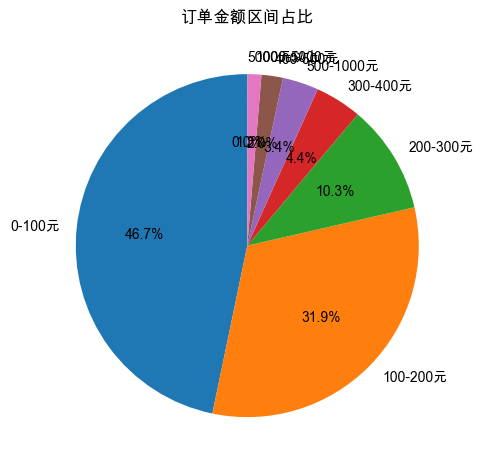

In [263]:
# 金额区间占比饼图
price_pct.plot.pie(autopct='%1.1f%%', startangle=90, title='订单金额区间占比')
plt.tight_layout() 
plt.ylabel('')  # 隐藏y轴标签
plt.show()

### 结论：
- 超过 75% 的订单金额在200元以内，说明平台以小额消费为主。500元-1000元订单仅占不到4%
- 结合之前的描述统计（最大值超过10万），这些少量高额订单（可能来自企业采购）显著拉高了整体均值。
- 建议运营策略可以针对高频低价区间做满减或包邮活动，同时单独分析高价值订单的用户特征，提供定制化服务。

###

## 3.2.2配送时效分析

### 3.2.2.1配送时长分布直方图

In [230]:
# 检查配送时长字段的缺失值比例
delivery_nan_pct = round(order_features['delivery_days'].isna().sum() / len(order_features) * 100,2)
delivery_nan_pct

np.float64(2.98)

### 结论：说明有2.98% 的订单未记录送达时间，可能为取消或未送达订单。占比不足3%，删除后对整体分布影响有限，不会导致样本偏差。

In [231]:
# 删除配送时长列的缺失值
delivered_days = order_features['delivery_days'].dropna()

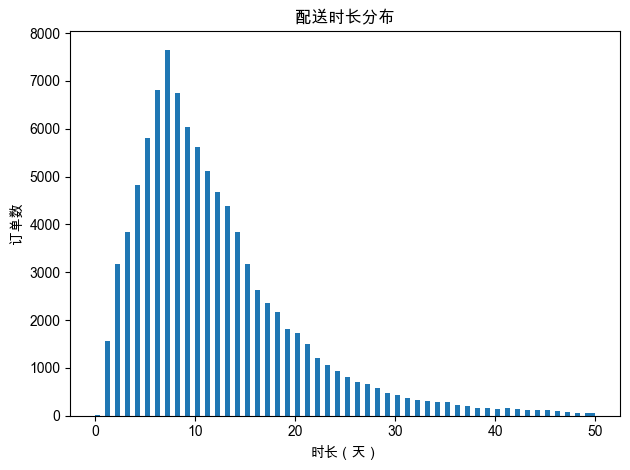

In [232]:
#配送时长分布直方图
delivered_days.plot.hist(bins=100, range=(0, 50), title='配送时长分布', 
                                          xlabel='时长（天）', ylabel='订单数')
plt.tight_layout() 
plt.show()

In [233]:
delivered_days.describe(percentiles=[.5, .9, .95])

count    96475.000000
mean        12.093651
std          9.550843
min          0.000000
50%         10.000000
90%         23.000000
95%         29.000000
max        209.000000
Name: delivery_days, dtype: float64

In [234]:
order_features['delivery_days'].value_counts().head()

delivery_days
7.0    7653
6.0    6805
8.0    6745
9.0    6039
5.0    5810
Name: count, dtype: int64

### 结论：
- 配送时长呈右偏分布，多数订单集中在 6-10 天，峰值在 7 天。
- 整体物流时效稳定，90% 订单能在 23 天内送达，中位数 10 天。
- 存在少量超长配送订单（超过 50 天），但数量极少，可单独作为异常分析。

### 3.2.2.2延迟订单占比饼图

Text(0, 0.5, '')

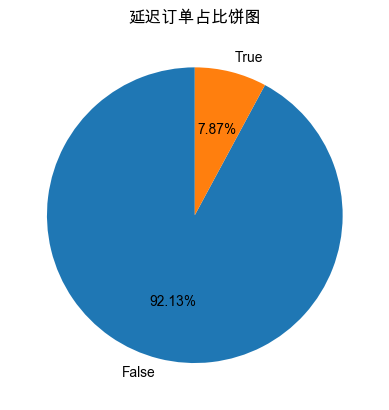

In [270]:
# 计算延迟订单的占比
late_counts = order_features['is_late'].value_counts()

# 延迟订单占比饼图
late_counts.plot.pie(title='延迟订单占比饼图', autopct='%1.2f%%', startangle=90)
plt.ylabel('')  # 隐藏y轴标签

### 结论:
- 绝大多数订单（92.13%）都能按时送达。
- 延迟订单占比 7.87%，属于合理范围，但仍有优化空间（例如分析延迟原因、地区差异等）。

#####

## 3.3产品表现分析

## 3.3.1品类销售排行

### 3.3.1.1销售额前10品类柱状图

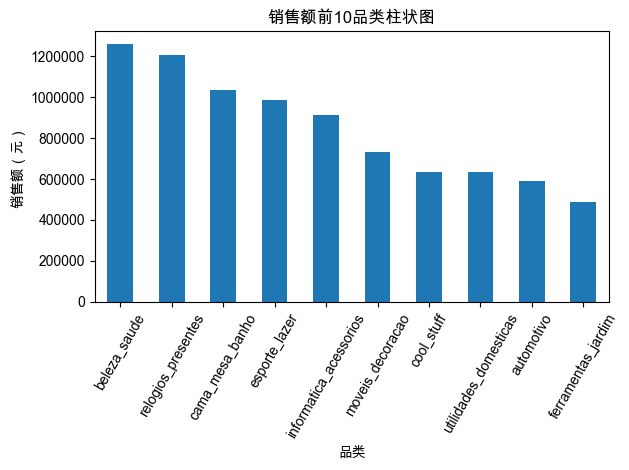

In [303]:
# 提取销售额最大的10行
category_top10_sales = category_features.nlargest(10, 'category_total_sales').set_index(
    'product_category_name')

# 销售额前10品类柱状图
ax = category_top10_sales['category_total_sales'].plot.bar(title='销售额前10品类柱状图', rot=60,
                                                      xlabel='品类', ylabel='销售额（元）')
ax.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

In [385]:
# 计算销售额在总销售额的占比
category_features['category_sales_pct'] = round(category_features[
    'category_total_sales'] / category_features['category_total_sales'].sum() * 100, 2)

# 提取销售额前10品类的销售额占比
category_top10_pct = category_features.nlargest(10,'category_sales_pct')[[
    'product_category_name', 'category_total_sales', 'category_sales_pct']]

# 设置category_sales_pct列的数字格式为百分比
category_top10_pct.style.format({'category_sales_pct':'{:.2f}%'})

,product_category_name,category_total_sales,category_sales_pct
11,beleza_saude,1258681.340000,9.26%
66,relogios_presentes,1205005.680000,8.87%
13,cama_mesa_banho,1036988.680000,7.63%
32,esporte_lazer,988048.970000,7.27%
44,informatica_acessorios,911954.320000,6.71%
54,moveis_decoracao,729762.490000,5.37%
26,cool_stuff,635290.850000,4.67%
73,utilidades_domesticas,632248.660000,4.65%
8,automotivo,592720.110000,4.36%
40,ferramentas_jardim,485256.460000,3.57%


In [390]:
# 计算销售额前10品类的销售占比之和
category_top10_pct['category_sales_pct'].sum()

np.float64(62.36)

### 结论：销售额前10的品类合计贡献了总销售额的 62.36%，呈现明显的头部集中效应。其中：

- beleza_saude（美容健康） 以 9.26% 的占比位居第一，销售额约 126 万元；
- relogios_presentes（手表礼品） 和 cama_mesa_banho（床单浴室） 分别以 8.87% 和 7.63% 紧随其后，三者合计占比 25.76%，构成核心销售品类。

#####

### 3.3.1.2销量前10品类柱状图

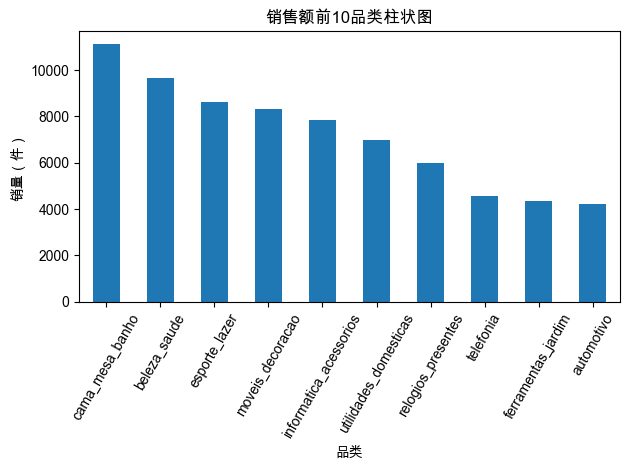

In [392]:
# 提取销量最大的10行
category_top10_count = category_features.nlargest(10, 'category_total_count').set_index(
    'product_category_name')

# 销量前10品类柱状图
category_top10_count['category_total_count'].plot.bar(title='销售额前10品类柱状图', rot=60,
                                                      xlabel='品类', ylabel='销量（件）')
plt.tight_layout()
plt.show()

In [389]:
# 计算销量在总销量占比
category_features['category_count_pct'] = round(category_features[
    'category_total_count'] / category_features['category_total_count'].sum() * 100, 2)

# 提取销量前10品类的销量占比
category_top10_count_pct = category_features.nlargest(10,'category_count_pct')[[
    'product_category_name', 'category_total_count', 'category_count_pct']]

# 设置category_count_pct列的数字格式为百分比
category_top10_count_pct.style.format({'category_count_pct':'{:.2f}%'})

,product_category_name,category_total_count,category_count_pct
13,cama_mesa_banho,11115,9.87%
11,beleza_saude,9670,8.58%
32,esporte_lazer,8641,7.67%
54,moveis_decoracao,8334,7.40%
44,informatica_acessorios,7827,6.95%
73,utilidades_domesticas,6964,6.18%
66,relogios_presentes,5991,5.32%
70,telefonia,4545,4.03%
40,ferramentas_jardim,4347,3.86%
8,automotivo,4235,3.76%


In [391]:
# 计算销量前10品类的销量占比之和
category_top10_count_pct['category_count_pct'].sum()

np.float64(63.62)

### 结论：销量前10品类分析：

销量前10的品类合计贡献了总销量的 63.6%，同样呈现头部集中趋势。其中：

- cama_mesa_banho（床单浴室） 以 11,115 件的销量位居榜首，占比 9.87%；
- beleza_saude（美容健康） 和 esporte_lazer（运动休闲） 分别以 9,670 件（8.58%）和 8,641 件（7.67%）紧随其后，三者合计占比 26.12%，构成销量主力。
  
与销售额前10品类对比：
- beleza_saude 在销售额和销量中均名列前茅，属于高价值高频品类；
- cama_mesa_banho 销量第一但销售额第三，可能单价较低，属于薄利多销型；
- 部分高销售额品类（如 relogios_presentes）未进入销量前十，说明其单品价值较高。

建议针对销量头部品类优化库存和促销策略，同时结合销售额数据识别不同品类的定位，实现差异化运营。